# MMC Chatbot — Advanced Analysis (Responses)

Topic modeling, mixed coding, needs mapping, and cross-cuts over the **946
chatbot users** in `MMC_bot_responses`. Companion to `analysis_meal.ipynb`
(satisfaction). Every section opens with **What this shows / Why it matters**;
non-obvious choices get a **Technical note**. Follow it top-to-bottom without
reading code.

> **Technical note — user-level, self-reported data.** One row per WhatsApp
> user; all of a user's messages are concatenated. There is no per-turn log and
> no bot-output text, which bounds what we can measure (see the final
> *Data gaps* section).

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from palette import *          # blue ramp, bar_colors(), rcParams
import mmc_data, mmc_entities, mmc_text

df = mmc_data.load_responses()
meal = mmc_data.load_meal()
print(f"responses: {len(df)} rows  |  meal: {len(meal)} rows")

responses: 946 rows  |  meal: 78 rows


## 1. Loading & cleaning

**What this shows.** How many users we have, how complete each field is, and
what cleaning was applied. **Why it matters.** Every later number rests on
these records being correctly parsed and de-duplicated.

In [2]:
summary = pd.DataFrame({
    "non_null": df.notna().sum(),
    "pct": (df.notna().mean() * 100).round(1),
})
display(summary.loc[["Nationality","city_clean","age_num","Gender",
                     "Minors","Messages","Chat_summary","n_questions","ts"]])
print("date range:", df["ts"].min(), "→", df["ts"].max())
print("unique phones:", df["phone"].nunique())

,non_null,pct
Nationality,919,97.1
city_clean,946,100.0
age_num,946,100.0
Gender,946,100.0
Minors,946,100.0
Messages,835,88.3
Chat_summary,844,89.2
n_questions,941,99.5
ts,946,100.0


date range: 2026-03-25 13:43:06.306000 → 2026-07-03 06:16:46.166000
unique phones: 917


## 2. Topic modeling & clustering

**What this shows.** Conversations grouped automatically by theme — no manual
labeling. **Why it matters.** It reveals what people actually ask about and
gives every later section a shared topic dimension.

> **Technical note.** We embed the English translation (`Text`) with the
> multilingual `paraphrase-multilingual-MiniLM-L12-v2` model, then let BERTopic
> (UMAP → HDBSCAN → c-TF-IDF) find clusters. `-1` is the outlier topic. A fixed
> `random_state` makes UMAP reproducible.

In [3]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic import BERTopic

docs_mask = df["Text"].notna() & (df["Text"].astype(str).str.len() > 0)
docs = df.loc[docs_mask, "Text"].astype(str).tolist()

embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = embedder.encode(docs, show_progress_bar=False)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric='cosine', random_state=42)
topic_model = BERTopic(umap_model=umap_model, language='multilingual',
                       min_topic_size=10, calculate_probabilities=False)
topics, _ = topic_model.fit_transform(docs, embeddings)

df["topic"] = -2                     # -2 = no text / not modeled
df.loc[docs_mask, "topic"] = topics
topic_info = topic_model.get_topic_info()
label_map = dict(zip(topic_info["Topic"], topic_info["Name"]))
label_map[-2] = "no message"
df["topic_label"] = df["topic"].map(label_map)
topic_info.head(20)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,169,-1_to_and_have_in,"[to, and, have, in, the, my, am, can, for, that]",[I need information about the temporary protec...
1,0,118,0_colombia_in_colombian_to,"[colombia, in, colombian, to, and, here, the, ...",[I am Venezuelan and I do not have documents i...
2,1,66,1_ppt_the_my_get,"[ppt, the, my, get, rumv, know, they, want, to...","[I can get the ppt, Can I get the PPT?, I want..."
3,2,59,2_safe_conduct_permit_pass,"[safe, conduct, permit, pass, residence, the, ...","[How do I apply for the safe-conduct pass?, Ho..."
4,3,49,3_hello_you_good_questions,"[hello, you, good, questions, re, welcome, yes...","[You're welcome, You're welcome, You're welcome]"
5,4,44,4_venezuelans_for_aid_venezuelan,"[venezuelans, for, aid, venezuelan, there, is,...",[I would like to know if there is any type of ...
6,5,43,5_humanitarian_aid_would_like,"[humanitarian, aid, would, like, know, assista...","[humanitarian aid, Humanitarian aid, Humanitar..."
7,6,33,6_job_employment_find_looking,"[job, employment, find, looking, want, get, to...","[I want to have a job, I want a job, I want a ..."
8,7,32,7_entrepreneurship_business_for_help,"[entrepreneurship, business, for, help, suppor...","[Entrepreneurship, Hello, I would like to know..."
9,8,29,8_health_help_me_need,"[health, help, me, need, hospital, don, marta,...",[I need help because I am in the hospital but ...


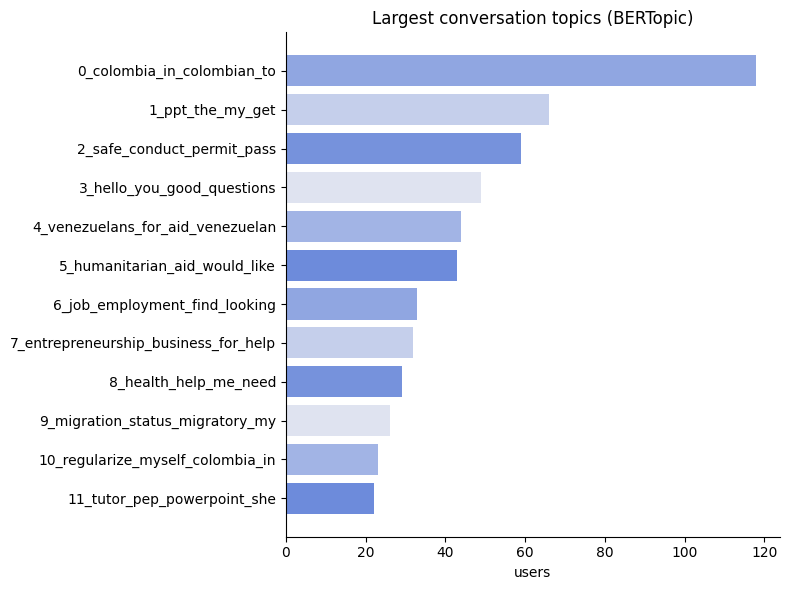

In [4]:
vis = topic_info[topic_info["Topic"] >= 0].head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(vis["Name"], vis["Count"], color=bar_colors(len(vis)))
ax.set_title("Largest conversation topics (BERTopic)")
ax.set_xlabel("users")
plt.tight_layout()